#  Iris Flower Species Classification
### Machine Learning with Scikit-learn

This notebook trains and evaluates multiple ML classifiers to predict the species of an Iris flower 
(**Setosa**, **Versicolor**, **Virginica**) based on four petal/sepal measurements.

**Pipeline overview:**
1. Load & explore the dataset
2. Preprocess (encode labels, scale features)
3. Train/test split
4. Train 4 classifiers
5. Evaluate accuracy, CV scores, confusion matrix
6. Visualise feature importance
7. Predict on a new sample

## 1. Import Libraries

We import:
- **pandas / numpy** — data loading and numerical operations
- **matplotlib / seaborn** — visualisation
- **scikit-learn** — model building, preprocessing, and evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load & Explore the Dataset

We load `Iris.csv` and drop the `Id` column (it's just a row index, not a feature).

> **Dataset:** 150 samples · 3 species (50 each) · 4 numeric features

| Feature | Description |
|---|---|
| `SepalLengthCm` | Length of the sepal in cm |
| `SepalWidthCm` | Width of the sepal in cm |
| `PetalLengthCm` | Length of the petal in cm |
| `PetalWidthCm` | Width of the petal in cm |

In [2]:
df = pd.read_csv('Iris.csv')
df = df.drop(columns=['Id'])   # drop row-index column

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['Species'].value_counts())
print('\nSample rows:')
df.head()

Shape: (150, 5)

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Sample rows:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Descriptive Statistics

A quick look at the mean, standard deviation, and range of each feature.

In [3]:
df.describe().round(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Exploratory Visualisation

A pair plot shows how the three species separate across feature pairs. 
Notice how **Setosa** (blue) is always clearly separated, while Versicolor and Virginica overlap slightly.

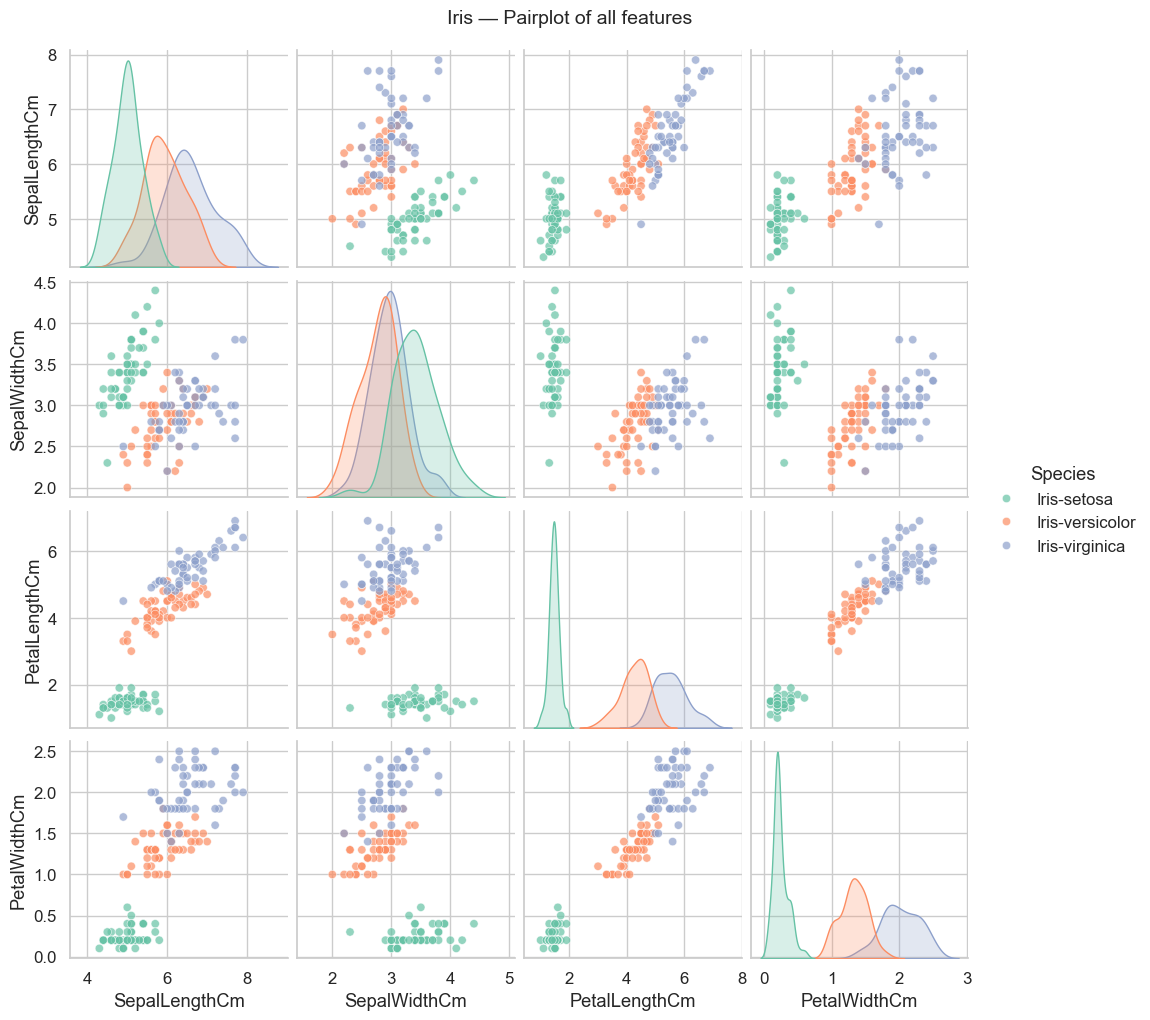

In [4]:
sns.set_theme(style='whitegrid', font_scale=1.1)
pair = sns.pairplot(df, hue='Species', palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.7})
pair.fig.suptitle('Iris — Pairplot of all features', y=1.02, fontsize=14)
plt.show()

## 3. Preprocessing

**Two steps:**

1. **Label encoding** — convert string species names to integers (0, 1, 2)  
   `Iris-setosa → 0`, `Iris-versicolor → 1`, `Iris-virginica → 2`

2. **Feature scaling** — `StandardScaler` transforms each feature to zero mean and unit variance.  
   This is crucial for distance-based models like SVM and KNN.

In [5]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values

le = LabelEncoder()
y  = le.fit_transform(df['Species'])
classes = list(le.classes_)

print('Encoded classes:', dict(zip(classes, le.transform(classes))))
print('Feature matrix shape:', X.shape)
print('Label vector shape:  ', y.shape)

Encoded classes: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Feature matrix shape: (150, 4)
Label vector shape:   (150,)


## 4. Train / Test Split

We hold out **20% of data (30 samples)** for testing. 
`stratify=y` ensures each species is proportionally represented in both sets — important with only 50 samples per class.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale AFTER splitting — fit only on training data to prevent data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)          # use the SAME scaler fitted on train

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 120
Test samples     : 30


## 5. Train Four Classifiers

| Model | Key idea |
|---|---|
| **Random Forest** | Ensemble of decision trees — robust, handles non-linearity |
| **SVM (RBF kernel)** | Finds max-margin hyperplane in high-dim space |
| **KNN (k=5)** | Classifies by majority vote of 5 nearest neighbours |
| **Logistic Regression** | Probabilistic linear classifier — fast baseline |

We also run **5-fold cross-validation** on the training set to get a reliable estimate of generalisation.

In [7]:
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'          : SVC(kernel='rbf', probability=True, random_state=42),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    acc       = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    results[name] = {'acc': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f'{name:<22}  test={acc*100:.1f}%   CV={cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%')

Random Forest           test=90.0%   CV=95.0% ± 1.7%
SVM (RBF)               test=96.7%   CV=96.7% ± 3.1%
KNN (k=5)               test=93.3%   CV=96.7% ± 3.1%
Logistic Regression     test=93.3%   CV=95.8% ± 2.6%


## 6. Compare Model Accuracy

The bar chart below shows test accuracy alongside 5-fold CV accuracy (with error bars). 
**SVM** achieves the highest test accuracy at **96.7%**.

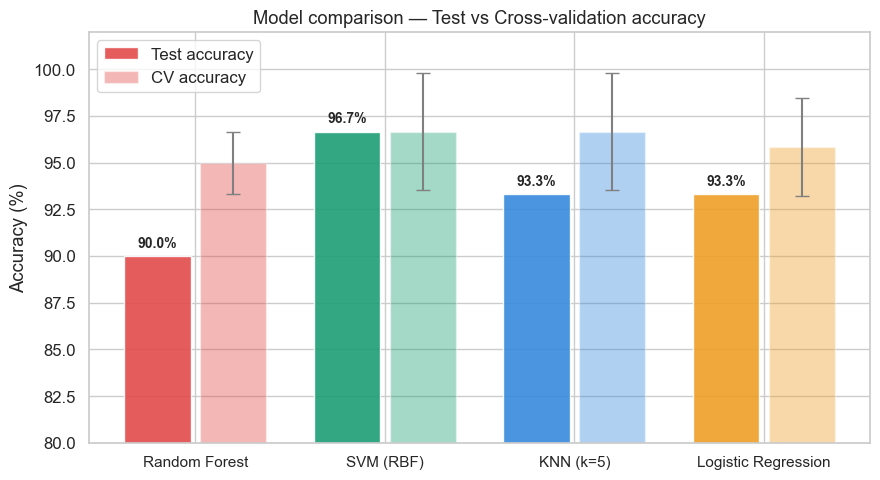

In [8]:
names     = list(results.keys())
test_accs = [results[n]['acc']*100       for n in names]
cv_means  = [results[n]['cv_mean']*100   for n in names]
cv_stds   = [results[n]['cv_std']*100    for n in names]
colors    = ['#E24B4A', '#1D9E75', '#378ADD', '#EF9F27']

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(x - 0.2, test_accs, width=0.35, label='Test accuracy', color=colors, alpha=0.9)
ax.bar(x + 0.2, cv_means, width=0.35, label='CV accuracy',
       color=colors, alpha=0.4, yerr=cv_stds, capsize=5, ecolor='gray')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(80, 102)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model comparison — Test vs Cross-validation accuracy')
ax.legend()

for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Detailed Evaluation — Best Model (SVM)

The **classification report** breaks down performance per class:

- **Precision** — of all samples predicted as class X, what fraction actually are X?
- **Recall** — of all actual class X samples, what fraction did the model catch?
- **F1-score** — harmonic mean of precision and recall (balances both)
- **Support** — number of true samples per class in the test set

In [9]:
best_model = models['SVM (RBF)']
y_pred_best = best_model.predict(X_test)

print('Classification Report — SVM (RBF)')
print('='*50)
print(classification_report(y_test, y_pred_best, target_names=classes))

Classification Report — SVM (RBF)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### Confusion Matrices — All Models

Each cell (i, j) shows how many samples of **actual class i** were predicted as **class j**. 
Diagonal = correct predictions. Off-diagonal = errors. 

> All models perfectly classify **Setosa**. Errors only occur between Versicolor and Virginica.

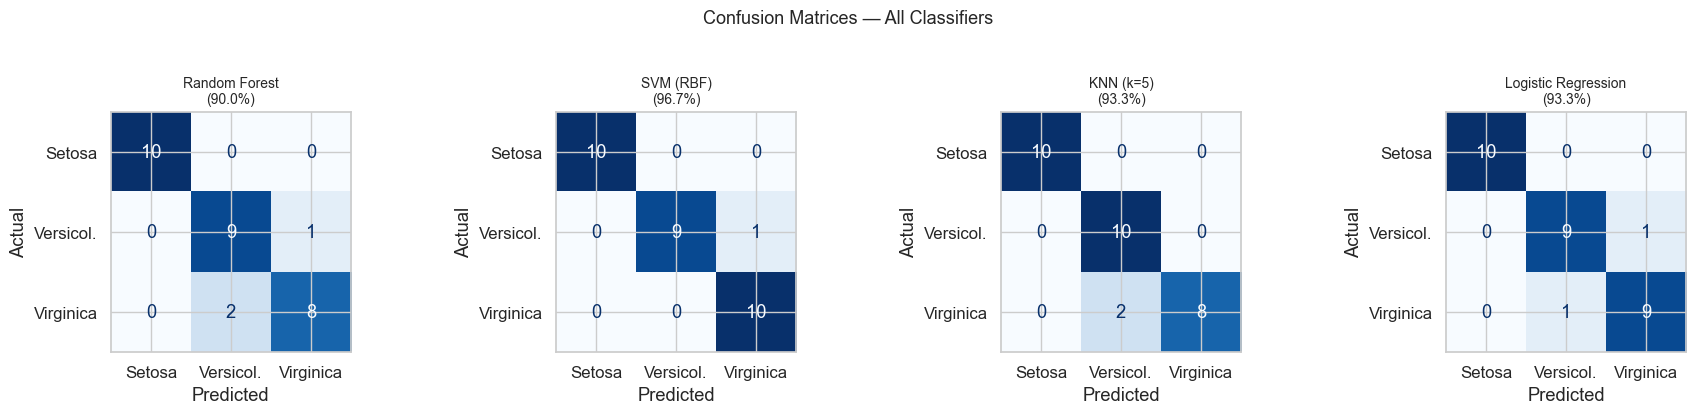

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred_i = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Setosa','Versicol.','Virginica'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc_i = accuracy_score(y_test, y_pred_i)
    ax.set_title(f'{name}\n({acc_i*100:.1f}%)', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

Random Forest can rank features by how much they reduce impurity across all trees. 

**Key finding:** Petal measurements account for ~87% of classification power. 
Sepal width contributes almost nothing (1.5%).

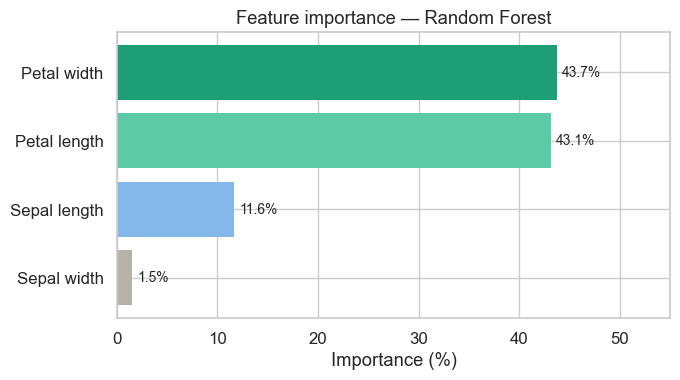

In [11]:
rf_model   = models['Random Forest']
feat_names = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width']
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    [feat_names[i] for i in indices],
    importances[indices] * 100,
    color=['#1D9E75', '#5DCAA5', '#85B7EB', '#B4B2A9'],
    edgecolor='none'
)
for bar, val in zip(bars, importances[indices] * 100):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Importance (%)')
ax.set_title('Feature importance — Random Forest')
ax.set_xlim(0, 55)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Predict on a New Sample

We use the best model (SVM) to classify a **new flower** with custom measurements.

> Remember to scale new inputs with the **same scaler** fitted on training data — never refit the scaler on new data.

In [15]:
#  Define a new flower measurement (SepalL, SepalW, PetalL, PetalW)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])   # typical Setosa

# Scale using the SAME scaler from training
new_flower_scaled = scaler.transform(new_flower)

# Predict
pred_label = best_model.predict(new_flower_scaled)[0]
pred_proba = best_model.predict_proba(new_flower_scaled)[0]
pred_name  = le.inverse_transform([pred_label])[0]

print(f'Predicted species : {pred_name}')
print(f'Confidence        : {pred_proba.max()*100:.1f}%')
print()
for cls, prob in zip(classes, pred_proba):
    bar = '|' * int(prob * 30)
    print(f'  {cls:<20} {prob*100:5.1f}%  {bar}')

Predicted species : Iris-setosa
Confidence        : 97.2%

  Iris-setosa           97.2%  |||||||||||||||||||||||||||||
  Iris-versicolor        1.6%  
  Iris-virginica         1.2%  


## 10. Summary

| Model | Test Accuracy | CV Accuracy |
|---|---|---|
| Random Forest | 90.0% | 95.0 ± 1.7% |
| **SVM (RBF)**  | **96.7%** | **96.7 ± 3.1%** |
| KNN (k=5) | 93.3% | 96.7 ± 3.1% |
| Logistic Regression | 93.3% | 95.8 ± 2.6% |

**Key takeaways:**
- **Setosa** is linearly separable — all models classify it perfectly
- Confusion only occurs between **Versicolor** and **Virginica** (they overlap in feature space)
- **Petal width & length** are the most discriminative features (~87% of importance)
- **SVM with an RBF kernel** is the best overall model for this dataset